# Load packages

In [2]:
#!pip install openpyxl

import pandas as pd
import scanpy as sc

import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np
from matplotlib.ticker import FormatStrFormatter
from scipy import stats
import matplotlib.patches as patches

# Load data

# Anastasis signatures

In [3]:
anastasis_sig = ['EGR1', 'FOSB', 'SNAI1', 'NR4A2', 'ATF3', 'DUSP1', 'JUN', 'EDN1',
                 'PPP1R15A', 'ADM', 'ZFP36', 'NR4A1', 'GADD45B', 'SOCS3', 'OTUD1',
                 'DUSP10', 'NR1D1', 'FOS', 'IER2', 'LOC284454', 'IER5', 'LOC644656',
                 'ID2', 'RSRP1', 'KLF11', 'NRARP', 'PIM1', 'CITED2', 'KLF10', 'KMT2E-AS1',
                 'CSRNP1', 'TRIM52', 'ING1', 'RHOB', 'CREBRF', 'ADRB2', 'JUNB', 'LINC00673',
                 'PHF13', 'ZBTB10', 'CEBPB']

In [4]:
# Convert the list to a DataFrame before saving to CSV
anastasis_df = pd.DataFrame({'gene': anastasis_sig})
anastasis_df.to_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/scRNA/anastasis_sig.csv', index=False)

## PCNA genes

In [5]:
PCNA_genes = pd.read_excel('/Users/wenqchen/Desktop/Projects/Auria/Data/scRNA/PCNAmetagene_human-mouse-homolgs.xlsx')

In [6]:
proliferation_genes = PCNA_genes['Human symbol'].dropna().unique().tolist()
proliferation_genes

['LMNB1',
 'NFE2',
 'KIF20A',
 'GTSE1',
 'FECH',
 'RRM2',
 'MCM4',
 'SMC4',
 'ALAS2',
 'CCNA2',
 'CCNB1',
 'GYPB',
 'LSM6',
 'RPIA',
 'CHAF1A',
 'POLE2',
 'FBXO7',
 'RPP30',
 'NCAPG2',
 'KEL',
 'MCM2',
 'GYPA',
 'ASF1B',
 'TOP2A',
 'TRMT5',
 'NUP37',
 'NCAPD2',
 'TACC3',
 'RAD51AP1',
 'FEN1',
 'LYL1',
 'KLF1',
 'VRK1',
 'RACGAP1',
 'DNAJC9',
 'CDCA3',
 'PGD',
 'TROAP',
 'TRIM58',
 'ADAMTS13',
 'KLF15',
 'CKS2',
 'RFC4',
 'TFDP1',
 'NUP210',
 'GATA1',
 'RFWD3',
 'HMGB2',
 'ESPL1',
 'CENPA',
 'PRC1',
 'SNRPD1',
 'RFC3',
 'RHCE',
 'ZWINT',
 'LBR',
 'CDKN3',
 'CDCA4',
 'FOXM1',
 'SHCBP1',
 'MICB',
 'GINS2',
 'FBXO5',
 'CKLF',
 'NCAPD3',
 'BPGM',
 'RHD',
 'TPX2',
 'CKS1B',
 'BIRC5',
 'MCM5',
 'MAD2L1',
 'TRIM10',
 'MCM6',
 'PSMD9',
 'GTPBP2',
 'CDC20',
 'KIF4A',
 'CCNB2',
 'RPA3',
 'MCM3',
 'TAL1',
 'PPIH',
 'KIF2C',
 'PTTG1',
 'KIF22',
 'EPB42',
 'CDCA8',
 'HMBS',
 'TIMELESS',
 'AURKB',
 'DTL',
 'RHAG',
 'PPBP',
 'TYMS',
 'CDT1',
 'SNRPB',
 'GINS1',
 'UBE2C',
 'SPTA1',
 'AURKA',
 'PLEK',
 

## adata

In [ ]:
# Read in the data
# Note: run once to convert the data to AnnData format
counts = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/scRNA/TNBC_counts.csv', index_col=0)
meta = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/scRNA/TNBC_metadata.csv', index_col=0)
adata = sc.AnnData(X=counts.T, obs=meta)
adata.write('/Users/wenqchen/Desktop/Projects/Auria/Data/scRNA/TNBC_adata.h5ad')

In [8]:
# read in the AnnData object
adata = sc.read('/Users/wenqchen/Desktop/Projects/Auria/Data/scRNA/TNBC_adata.h5ad')

In [9]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,NAME,Patient,Percent_mito,celltype_major,celltype_minor,celltype_subset,subtype,...,CNA_value,oxstress,treatment,age,cancer_type,GCLCVIM,signature_GCLCVIM,signature_GCLCVIMTUMOR,signature_anastasis,signature_proliferation
CID4465_AAACGGGTCATCGATG,CID4465,1277,799,CID4465_AAACGGGTCATCGATG,CID4465,2.662490,Endothelial,Endothelial ACKR1,Endothelial ACKR1,TNBC,...,no_CNA_value,0.063201,Naïve,54,IDC,-+,0.176422,0.176843,0.331157,-0.036520
CID4465_AAACGGGTCGGAAACG,CID4465,478,339,CID4465_AAACGGGTCGGAAACG,CID4465,3.556485,Endothelial,Endothelial ACKR1,Endothelial ACKR1,TNBC,...,no_CNA_value,0.075607,Naïve,54,IDC,-+,0.095979,0.114641,0.521046,-0.008995
CID4465_AAAGATGAGGTGTGGT,CID4465,1495,878,CID4465_AAAGATGAGGTGTGGT,CID4465,3.879599,Endothelial,Endothelial ACKR1,Endothelial ACKR1,TNBC,...,no_CNA_value,0.111242,Naïve,54,IDC,--,0.115277,0.126621,0.617526,-0.024047
CID4465_AAAGCAATCCTTTACA,CID4465,723,457,CID4465_AAAGCAATCCTTTACA,CID4465,3.181189,Endothelial,Endothelial ACKR1,Endothelial ACKR1,TNBC,...,no_CNA_value,0.044548,Naïve,54,IDC,--,0.039549,0.050179,0.491101,-0.055846
CID4465_AACCATGGTACGCTGC,CID4465,1977,1074,CID4465_AACCATGGTACGCTGC,CID4465,6.120384,Endothelial,Endothelial ACKR1,Endothelial ACKR1,TNBC,...,no_CNA_value,0.113377,Naïve,54,IDC,-+,0.131447,0.130072,0.435326,-0.064722
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CID3963_GAACCTACACAGATTC,CID3963,1316,566,CID3963_GAACCTACACAGATTC,CID3963,0.303951,Cancer Epithelial,Cancer LumA SC,Cancer LumA SC,TNBC,...,0.280199512,0.082146,Treated,61,IDC,--,0.082191,0.171436,-0.308466,-0.001009
CID3963_GCATGCGGTTCGAATC,CID3963,1372,575,CID3963_GCATGCGGTTCGAATC,CID3963,0.437318,Cancer Epithelial,Cancer LumA SC,Cancer LumA SC,TNBC,...,0.231542891,0.204991,Treated,61,IDC,--,0.020497,0.092769,-0.302699,0.045975
CID3963_GTACGTAGTGAGGGAG,CID3963,3247,1167,CID3963_GTACGTAGTGAGGGAG,CID3963,14.875269,Cancer Epithelial,Cancer LumA SC,Cancer LumA SC,TNBC,...,0.298488317,0.142501,Treated,61,IDC,--,0.104554,0.180978,0.353898,-0.004652
CID3963_TATTACCTCTTACCTA,CID3963,6043,1712,CID3963_TATTACCTCTTACCTA,CID3963,15.224226,Cancer Epithelial,Cancer Her2 SC,Cancer Her2 SC,TNBC,...,0.228002684,0.152117,Treated,61,IDC,--,0.067952,0.145327,1.345855,0.006607


# proliferation_score

In [10]:
sc.tl.score_genes(adata, gene_list = proliferation_genes, score_name = 'proliferation_score')

       'MLF1IP', 'BZRPL1'],
      dtype='object')


In [11]:
name = adata.var_names
# Create a DataFrame with the gene names for better organization
gene_df = pd.DataFrame(index=name)
gene_df['gene_name'] = name
# Check if any of these genes are in our proliferation gene list
gene_df['is_proliferation_gene'] = gene_df.index.isin(proliferation_genes)
gene_df.to_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/scRNA/TNBC_var_names.csv')

In [ ]:
adata_tumor = adata[adata.obs['celltype_major'] == 'Cancer Epithelial']
adata_tumor.obs

In [33]:
adata_tumor.obs['GCLCVIM'].value_counts()

GCLCVIM
--    6972
-+    2854
++     506
+-     504
Name: count, dtype: int64

In [43]:
df_scores = pd.DataFrame(adata_tumor.obs[['Patient', 'GCLCVIM', 'signature_anastasis', 'signature_proliferation', 'proliferation_score']])

In [44]:
# Example: subsample each group to 500
balanced_df_scores = df_scores.groupby("GCLCVIM").apply(lambda x: x.sample(n=500, random_state=0)).reset_index(drop=True)

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_61748/461993407.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  balanced_df_scores = df_scores.groupby("GCLCVIM").apply(lambda x: x.sample(n=500, random_state=0)).reset_index(drop=True)
/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_61748/461993407.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df_scores = df_scores.groupby("GCLCVIM").apply(lambda x: x.sample(n=500, random_state=0)).reset_index(drop=True)


In [45]:
balanced_df_scores

,Patient,GCLCVIM,signature_anastasis,signature_proliferation,proliferation_score
0,CID4515,++,-0.184580,0.182867,0.243887
1,CID4515,++,-0.042383,0.256477,0.311330
2,CID4513,++,-0.032831,-0.092503,-0.049175
3,CID4515,++,-0.322298,-0.029930,0.028973
4,CID4513,++,-0.256326,0.337011,0.397083
...,...,...,...,...,...
1995,CID44991,--,0.362023,-0.094650,-0.066194
1996,CID44991,--,0.334632,-0.015646,0.005194
1997,CID44991,--,0.439455,0.074691,0.114848
1998,CID4495,--,-0.207551,0.021660,0.010351


# Function: Plot density by group

In [46]:
def plot_density_by_group(data, 
                         x_var='proliferation_score', 
                         group_var='GCLCVIM', 
                         palette=None,
                         reference_group='++',
                         figsize=(10, 6),
                         title=None,
                         output_file=None,
                         show=True):
    """
    Create a density plot with statistical comparisons between groups.
    
    Parameters:
    -----------
    data : pd.DataFrame
        DataFrame containing the data
    x_var : str
        Variable to plot on x-axis
    group_var : str
        Variable used for grouping
    palette : dict
        Color palette for groups
    reference_group : str
        Group to use as reference for statistical comparisons
    figsize : tuple
        Figure size
    title : str
        Plot title
    output_file : str
        Path to save the figure
    show : bool
        Whether to show the plot
    
    Returns:
    --------
    fig, ax : tuple
        Figure and axes objects
    """
    
    # Use the provided palette or default
    if palette is None:
        palette = {'++': '#F0776D', '+-': '#FBD2CB', '-+': '#a9d9bb', '--': '#337bac'}
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create ridge plot (density plot)
    sns.kdeplot(
        data=data, 
        x=x_var, 
        hue=group_var,
        palette=palette,
        fill=True,
        common_norm=False,
        alpha=0.5,
        linewidth=2
    )
    
    # Calculate statistics - compare reference group with other groups
    ref_data = data[data[group_var] == reference_group][x_var]
    result_text = []
    
    for group in [g for g in data[group_var].unique() if g != reference_group]:
        group_data = data[data[group_var] == group][x_var]
        # Perform Mann-Whitney U test (non-parametric)
        stat, pval = stats.mannwhitneyu(ref_data, group_data)
        
        # Format significance stars
        if pval < 0.001:
            sig = '***'
        elif pval < 0.01:
            sig = '**'
        elif pval < 0.05:
            sig = '*'
        else:
            sig = 'ns'
            
        result_text.append(f"{reference_group} vs {group}: {sig} (p={pval:.2e})")
    
    # Add statistics as text box
    ax.text(0.02, 0.98, '\n'.join(result_text), transform=ax.transAxes, 
            bbox=dict(facecolor='white', alpha=0.8), va='top', fontsize=9)
    
    # Customize plot
    plt.xlabel(x_var.replace('_', ' ').title())
    plt.ylabel('Density')
    plt.title(title or f"{x_var.replace('_', ' ').title()} Distribution by {group_var}")
    plt.grid(alpha=0.3)
    
    # Add mean lines
    for group in data[group_var].unique():
        mean_val = data[data[group_var] == group][x_var].mean()
        plt.axvline(x=mean_val, color=palette[group], linestyle='--', 
                    alpha=0.7, label=f'Mean {group}: {mean_val:.3f}')
    
    plt.legend(title=f"{group_var} Group")
    plt.tight_layout()
    
    if output_file:
        plt.savefig(output_file, dpi=500)
    
    if show:
        plt.show()
        
    return fig, ax, result_text

In [26]:
def plot_violin_with_significance(
    data,
    x,
    y,
    stat_results,
    palette=None,
    reference_group=None,
    comparison_groups=None,
    figsize=(7, 5.5),
    xlabel=None,
    ylabel=None,
    title=None,
    output_file=None,
    show=True
):
    """
    Create a violin plot with significance bars.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        DataFrame containing the data
    x : str
        Column name for x-axis (grouping variable)
    y : str
        Column name for y-axis (measurement variable)
    stat_results : list
        List of strings containing statistical results (e.g., '++ vs --: *** (p=1.90e-19)')
    palette : dict
        Color palette for groups
    reference_group : str
        Reference group for comparisons
    comparison_groups : list
        List of groups to compare with the reference
    figsize : tuple
        Figure size (width, height)
    xlabel : str
        Label for x-axis
    ylabel : str
        Label for y-axis
    title : str
        Plot title
    output_file : str
        Path to save the figure
    show : bool
        Whether to show the plot
    """
    
    # Default palette if none provided
    if palette is None:
        palette = {'++': '#F0776D', '+-': '#FBD2CB', '-+': '#a9d9bb', '--': '#337bac'}
    
    # Create the plot
    plt.figure(figsize=figsize)
    ax = sns.violinplot(data=data, x=x, y=y, palette=palette)
    
    # Set labels
    plt.xlabel(xlabel or x)
    if ylabel:
        plt.ylabel(ylabel)
    if title:
        plt.title(title)
    
    # Get unique groups and determine reference/comparison groups if not provided
    unique_groups = data[x].unique()
    
    if reference_group is None and len(unique_groups) > 0:
        # Try to extract from stat_results or use first group
        if stat_results and ' vs ' in stat_results[0]:
            reference_group = stat_results[0].split(' vs ')[0]
        else:
            reference_group = unique_groups[0]
        
    if comparison_groups is None:
        # Try to extract from stat_results or use all non-reference groups
        comparison_groups = []
        for result in stat_results:
            if ' vs ' in result:
                comp = result.split(' vs ')[1].split(':')[0]
                comparison_groups.append(comp)
        if not comparison_groups:
            comparison_groups = [g for g in unique_groups if g != reference_group]
    
    # Get the x-coordinates of the violin centers
    x_positions = {group: i for i, group in enumerate(data[x].unique())}
    
    # Define parameters for the significance bars
    y_max = data[y].max()
    bar_height = y_max * 0.1  # Height increment for bars
    text_height = y_max * 0.02  # Text offset
    
    # Add significance bars
    for i, result in enumerate(stat_results):
        # Extract significance stars from the result
        sig_stars = result.split(': ')[1].split(' ')[0]
        
        # Extract comparison group
        if len(comparison_groups) > i:
            comparison = comparison_groups[i]
        else:
            comparison = result.split(' vs ')[1].split(':')[0]
        
        # Calculate bar positions
        x1 = x_positions[reference_group]
        x2 = x_positions[comparison]
        y = y_max + (i+1) * bar_height
        
        # Add the bar
        plt.plot([x1, x2], [y, y], 'k-', linewidth=1.5)
        plt.plot([x1, x1], [y-bar_height*0.2, y], 'k-', linewidth=1.5)
        plt.plot([x2, x2], [y-bar_height*0.2, y], 'k-', linewidth=1.5)
        
        # Add the significance stars
        plt.text((x1+x2)/2, y+text_height, sig_stars, ha='center', va='center')

    plt.ylim(top=y_max + (len(stat_results)+1) * bar_height)
    plt.tight_layout()
    
    if output_file:
        plt.savefig(output_file, dpi=500)
    
    if show:
        plt.show()

# Run function

## proliferation score

### Python

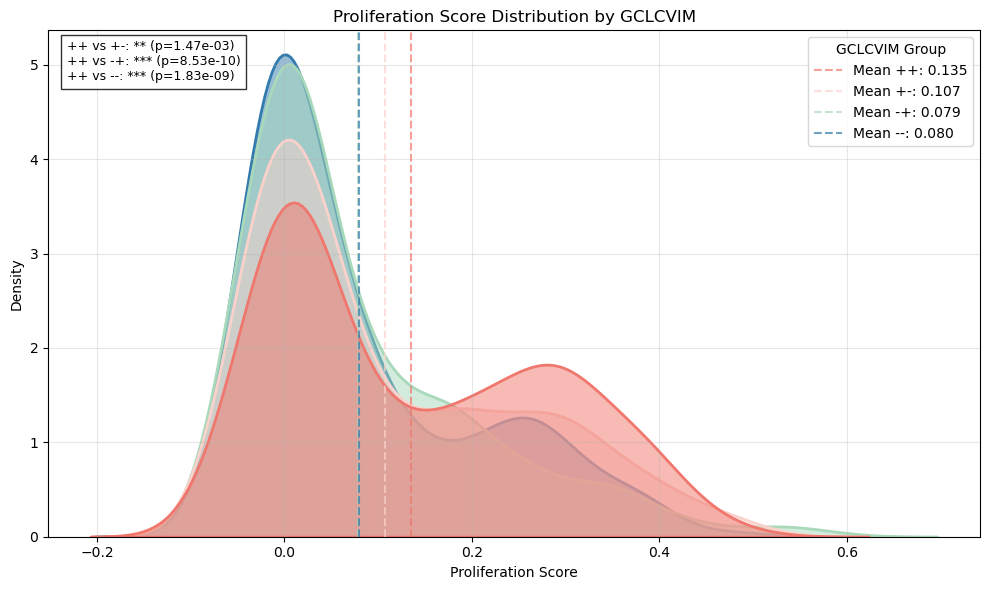

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Proliferation Score Distribution by GCLCVIM'}, xlabel='Proliferation Score', ylabel='Density'>,
 ['++ vs +-: ** (p=1.47e-03)',
  '++ vs -+: *** (p=8.53e-10)',
  '++ vs --: *** (p=1.83e-09)'])

In [ ]:
# Select 500 cells from each group randomly
plot_density_by_group(data = balanced_df_scores, 
                         x_var='proliferation_score', 
                         group_var='GCLCVIM', 
                         palette={'++': '#F0776D', '+-': '#FBD2CB', '-+': '#a9d9bb', '--': '#337bac'},
                         reference_group='++',
                         figsize=(10, 6),
                         title=None,
                         output_file='/Users/wenqchen/Desktop/Projects/Auria/Plots/scRNA/Signature_score/random_500cells/Proliferation_score_GCLCVIM_density_sc.pdf',
                         show=True)

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_61748/2683523664.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=data, x=x, y=y, palette=palette)


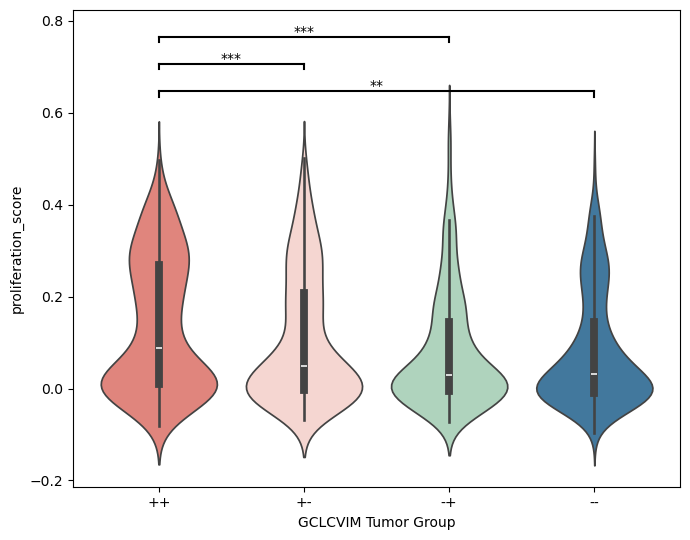

In [50]:
stat_results = [
    '++ vs +-: ** (p=1.47e-03)',
    '++ vs -+: *** (p=8.53e-10)',
    '++ vs --: *** (p=1.83e-09)'
]
palette = {'++': '#F0776D', '+-': '#FBD2CB', '-+': '#a9d9bb', '--': '#337bac'}

plot_violin_with_significance(
    data = balanced_df_scores,
    x='GCLCVIM',
    y='proliferation_score',
    stat_results = stat_results,
    palette = palette,
    reference_group = '++',
    comparison_groups = ['--', '+-', '-+'],
    figsize = (7, 5.5),
    xlabel = 'GCLCVIM Tumor Group',
    ylabel = None,
    title = None,
    output_file = '/Users/wenqchen/Desktop/Projects/Auria/Plots/scRNA/Signature_score/random_500cells/Proliferation_score_GCLCVIM_violin_sc.pdf',
    show = True
)

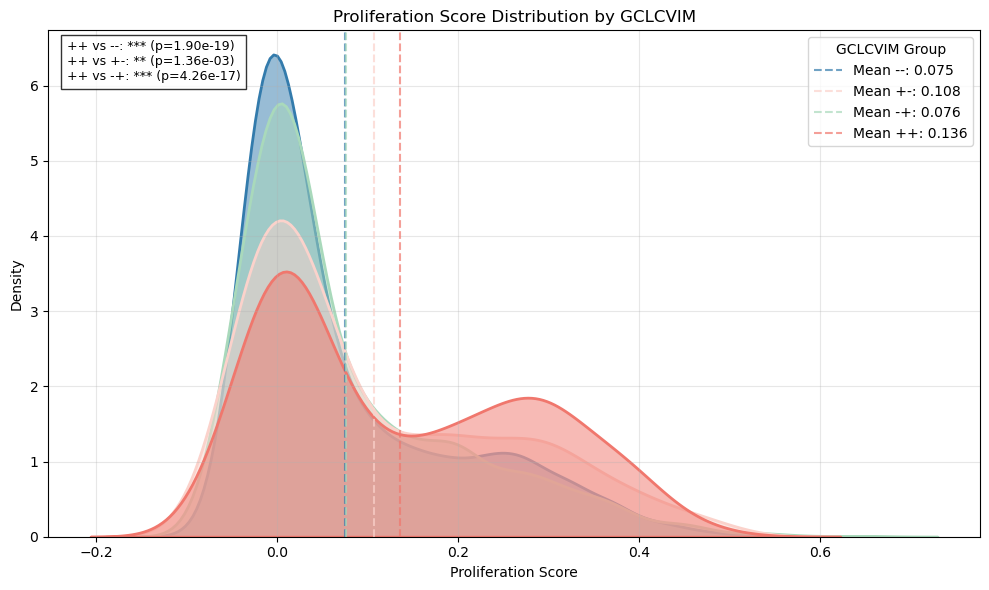

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Proliferation Score Distribution by GCLCVIM'}, xlabel='Proliferation Score', ylabel='Density'>,
 ['++ vs --: *** (p=1.90e-19)',
  '++ vs +-: ** (p=1.36e-03)',
  '++ vs -+: *** (p=4.26e-17)'])

In [47]:
plot_density_by_group(data = df_scores, 
                         x_var='proliferation_score', 
                         group_var='GCLCVIM', 
                         palette={'++': '#F0776D', '+-': '#FBD2CB', '-+': '#a9d9bb', '--': '#337bac'},
                         reference_group='++',
                         figsize=(10, 6),
                         title=None,
                         output_file='/Users/wenqchen/Desktop/Projects/Auria/Plots/scRNA/Signature_score/Proliferation_score_GCLCVIM_density_sc.pdf',
                         show=True)


/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_61748/2683523664.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=data, x=x, y=y, palette=palette)


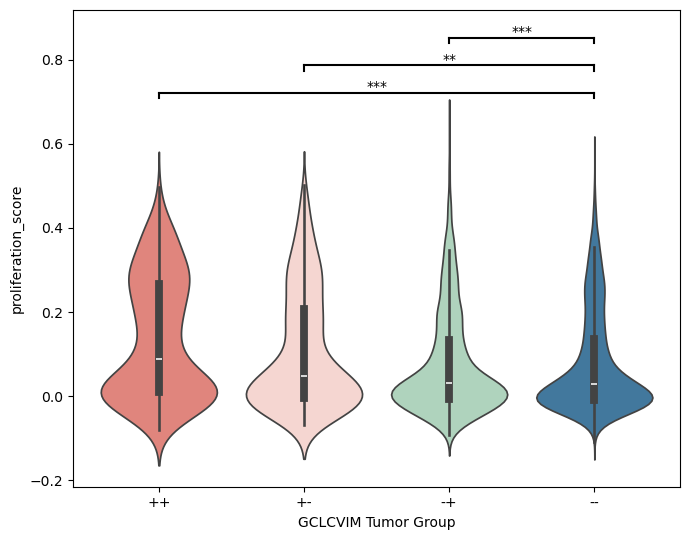

In [ ]:
stat_results = [
    '++ vs --: *** (p=1.90e-19)',
    '++ vs +-: ** (p=1.36e-03)',
    '++ vs -+: *** (p=4.26e-17)'
]
palette = {'++': '#F0776D', '+-': '#FBD2CB', '-+': '#a9d9bb', '--': '#337bac'}

plot_violin_with_significance(
    data = df_scores,
    x='GCLCVIM',
    y='proliferation_score',
    stat_results = stat_results,
    palette = palette,
    reference_group = '++',
    comparison_groups = ['--', '+-', '-+'],
    figsize = (7, 5.5),
    xlabel = 'GCLCVIM Tumor Group',
    ylabel = None,
    title = None,
    output_file = '/Users/wenqchen/Desktop/Projects/Auria/Plots/scRNA/Signature_score/Proliferation_score_GCLCVIM_violin_sc.pdf',
    show = True
)


### R Seurat

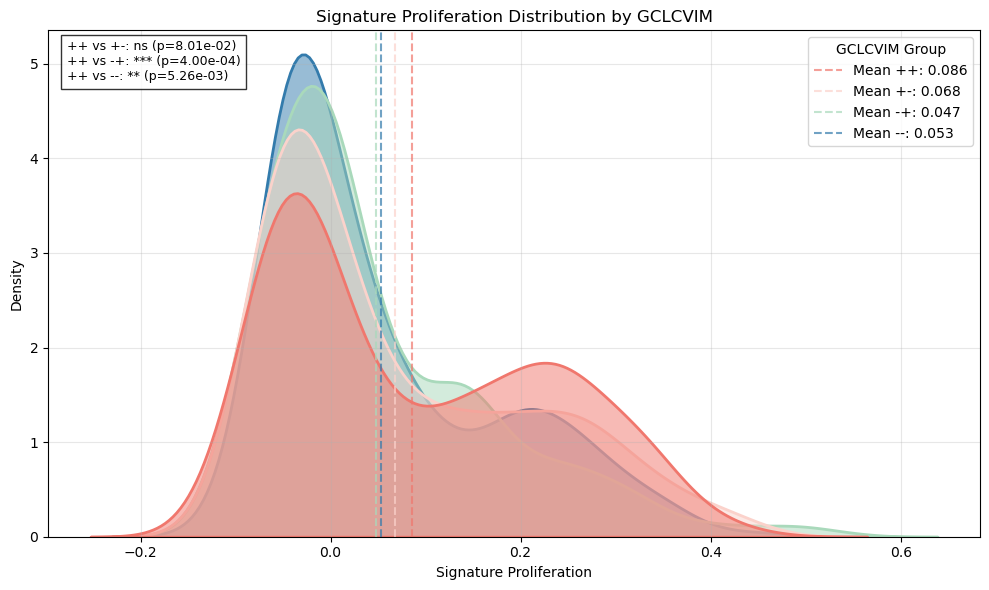

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Signature Proliferation Distribution by GCLCVIM'}, xlabel='Signature Proliferation', ylabel='Density'>,
 ['++ vs +-: ns (p=8.01e-02)',
  '++ vs -+: *** (p=4.00e-04)',
  '++ vs --: ** (p=5.26e-03)'])

In [51]:
plot_density_by_group(balanced_df_scores, 
                         x_var='signature_proliferation', 
                         group_var='GCLCVIM', 
                         palette={'++': '#F0776D', '+-': '#FBD2CB', '-+': '#a9d9bb', '--': '#337bac'},
                         reference_group='++',
                         figsize=(10, 6),
                         title=None,
                         output_file='/Users/wenqchen/Desktop/Projects/Auria/Plots/scRNA/Signature_score/random_500cells/Proliferation_score_GCLCVIM_density_seurat.pdf',
                         show=True)

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_61748/2683523664.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=data, x=x, y=y, palette=palette)


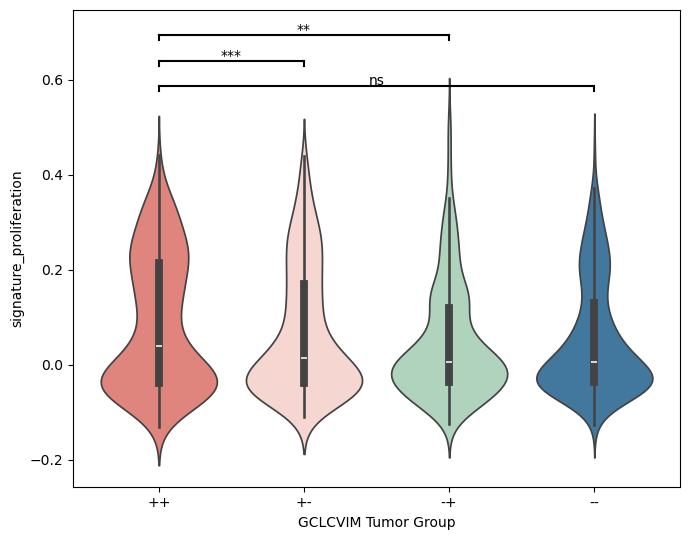

In [52]:
stat_results = [
    '++ vs +-: ns (p=8.01e-02)',
    '++ vs -+: *** (p=4.00e-04)',
    '++ vs --: ** (p=5.26e-03)'
]
palette = {'++': '#F0776D', '+-': '#FBD2CB', '-+': '#a9d9bb', '--': '#337bac'}

plot_violin_with_significance(
    data = balanced_df_scores,
    x='GCLCVIM',
    y='signature_proliferation',
    stat_results = stat_results,
    palette = palette,
    reference_group = '++',
    comparison_groups = ['--', '+-', '-+'],
    figsize = (7, 5.5),
    xlabel = 'GCLCVIM Tumor Group',
    ylabel = None,
    title = None,
    output_file = '/Users/wenqchen/Desktop/Projects/Auria/Plots/scRNA/Signature_score/random_500cells/Proliferation_score_GCLCVIM_violin_seurat.pdf',
    show = True
)

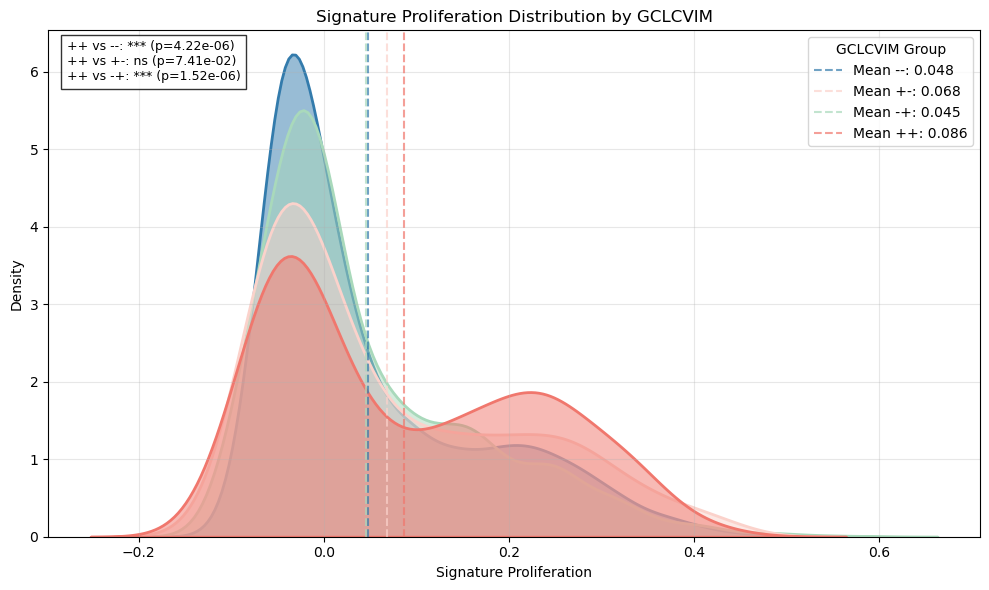

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Signature Proliferation Distribution by GCLCVIM'}, xlabel='Signature Proliferation', ylabel='Density'>,
 ['++ vs --: *** (p=4.22e-06)',
  '++ vs +-: ns (p=7.41e-02)',
  '++ vs -+: *** (p=1.52e-06)'])

In [ ]:
plot_density_by_group(df_scores, 
                         x_var='signature_proliferation', 
                         group_var='GCLCVIM', 
                         palette={'++': '#F0776D', '+-': '#FBD2CB', '-+': '#a9d9bb', '--': '#337bac'},
                         reference_group='++',
                         figsize=(10, 6),
                         title=None,
                         output_file='/Users/wenqchen/Desktop/Projects/Auria/Plots/scRNA/Signature_score/Proliferation_score_GCLCVIM_density_seurat.pdf',
                         show=True)

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_61748/2683523664.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=data, x=x, y=y, palette=palette)


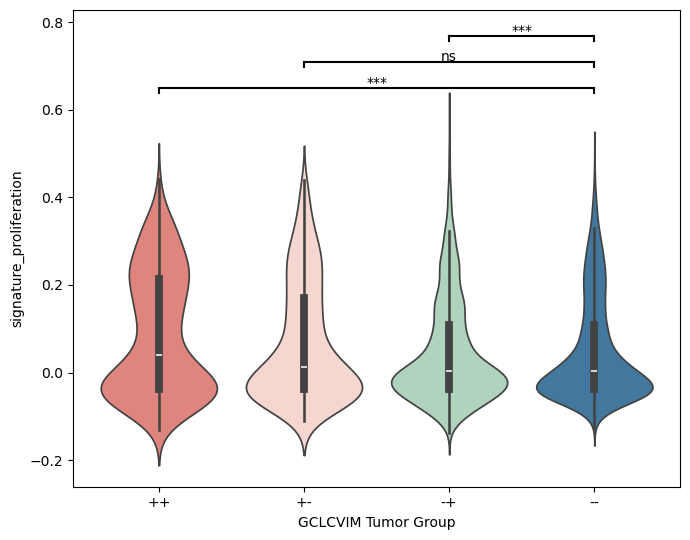

In [ ]:
stat_results = [
    '++ vs --: *** (p=4.22e-06)',
    '++ vs +-: ns (p=7.41e-02)',
    '++ vs -+: *** (p=1.52e-06)'
]
palette = {'++': '#F0776D', '+-': '#FBD2CB', '-+': '#a9d9bb', '--': '#337bac'}

plot_violin_with_significance(
    data = df_scores,
    x='GCLCVIM',
    y='signature_proliferation',
    stat_results = stat_results,
    palette = palette,
    reference_group = '++',
    comparison_groups = ['--', '+-', '-+'],
    figsize = (7, 5.5),
    xlabel = 'GCLCVIM Tumor Group',
    ylabel = None,
    title = None,
    output_file = '/Users/wenqchen/Desktop/Projects/Auria/Plots/scRNA/Signature_score/Proliferation_score_GCLCVIM_violin_seurat.pdf',
    show = True
)

## anastasis score

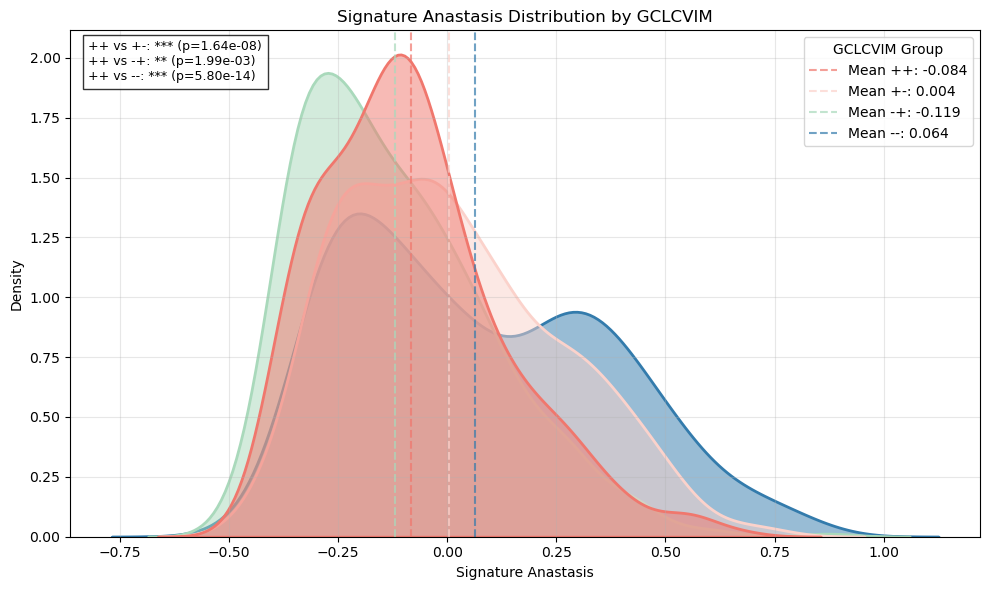

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Signature Anastasis Distribution by GCLCVIM'}, xlabel='Signature Anastasis', ylabel='Density'>,
 ['++ vs +-: *** (p=1.64e-08)',
  '++ vs -+: ** (p=1.99e-03)',
  '++ vs --: *** (p=5.80e-14)'])

In [53]:
plot_density_by_group(balanced_df_scores, 
                         x_var='signature_anastasis', 
                         group_var='GCLCVIM', 
                         palette={'++': '#F0776D', '+-': '#FBD2CB', '-+': '#a9d9bb', '--': '#337bac'},
                         reference_group='++',
                         figsize=(10, 6),
                         title=None,
                         output_file='/Users/wenqchen/Desktop/Projects/Auria/Plots/scRNA/Signature_score/random_500cells/Anastasis_score_GCLCVIM_density_seurat.pdf',
                         show=True)

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_61748/2683523664.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=data, x=x, y=y, palette=palette)


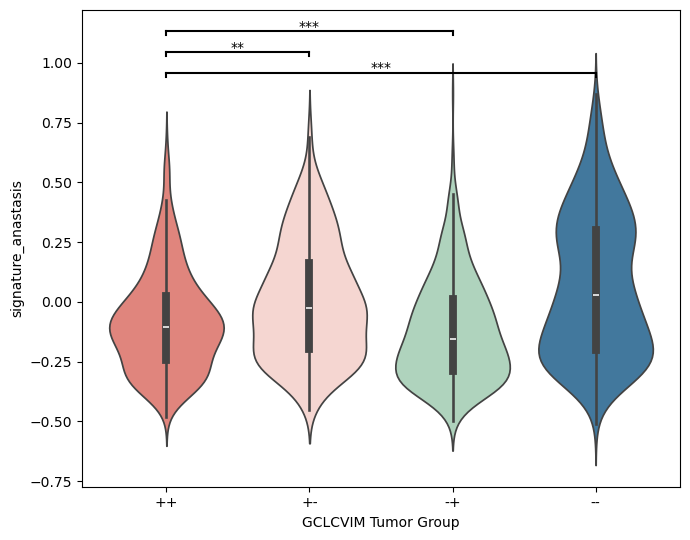

In [54]:
stat_results = [
    '++ vs +-: *** (p=1.64e-08)',
    '++ vs -+: ** (p=1.99e-03)',
    '++ vs --: *** (p=5.80e-14)'
]
palette = {'++': '#F0776D', '+-': '#FBD2CB', '-+': '#a9d9bb', '--': '#337bac'}

plot_violin_with_significance(
    data = balanced_df_scores,
    x='GCLCVIM',
    y='signature_anastasis',
    stat_results = stat_results,
    palette = palette,
    reference_group = '++',
    comparison_groups = ['--', '+-', '-+'],
    figsize = (7, 5.5),
    xlabel = 'GCLCVIM Tumor Group',
    ylabel = None,
    title = None,
    output_file = '/Users/wenqchen/Desktop/Projects/Auria/Plots/scRNA/Signature_score/random_500cells/Anastasis_score_GCLCVIM_violin_seurat.pdf',
    show = True
)

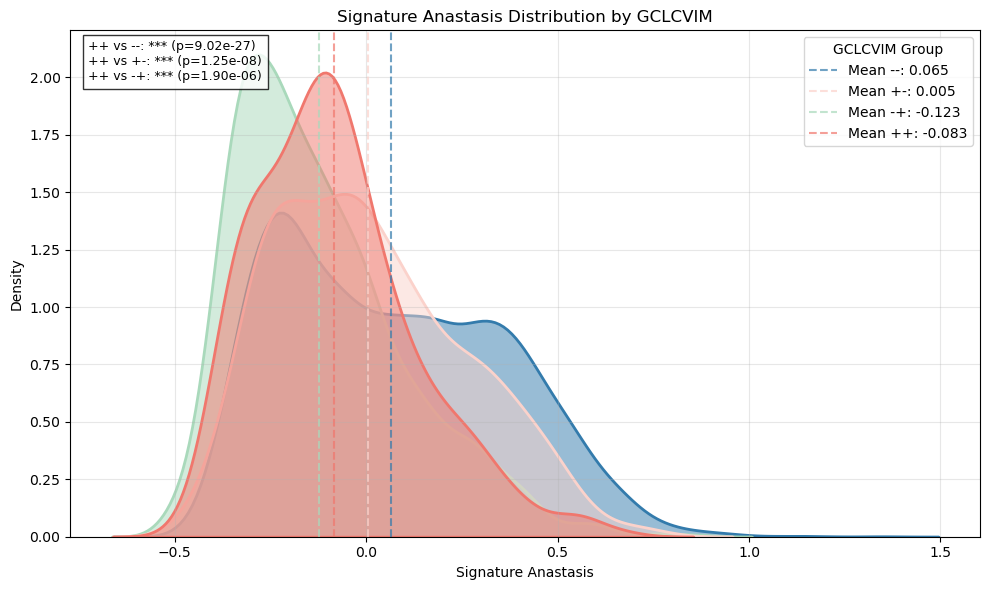

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Signature Anastasis Distribution by GCLCVIM'}, xlabel='Signature Anastasis', ylabel='Density'>,
 ['++ vs --: *** (p=9.02e-27)',
  '++ vs +-: *** (p=1.25e-08)',
  '++ vs -+: *** (p=1.90e-06)'])

In [ ]:
plot_density_by_group(df_scores, 
                         x_var='signature_anastasis', 
                         group_var='GCLCVIM', 
                         palette={'++': '#F0776D', '+-': '#FBD2CB', '-+': '#a9d9bb', '--': '#337bac'},
                         reference_group='++',
                         figsize=(10, 6),
                         title=None,
                         output_file='/Users/wenqchen/Desktop/Projects/Auria/Plots/scRNA/Signature_score/Anastasis_score_GCLCVIM_density_seurat.pdf',
                         show=True)

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_61748/2683523664.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=data, x=x, y=y, palette=palette)


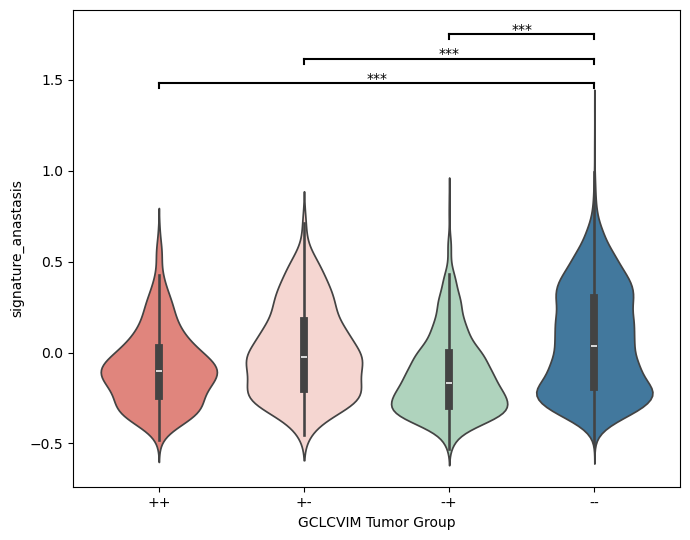

In [ ]:
stat_results = [
    '++ vs --: *** (p=9.02e-27)',
    '++ vs +-: *** (p=1.25e-08)',
    '++ vs -+: *** (p=1.90e-06)'
]
palette = {'++': '#F0776D', '+-': '#FBD2CB', '-+': '#a9d9bb', '--': '#337bac'}

plot_violin_with_significance(
    data = df_scores,
    x='GCLCVIM',
    y='signature_anastasis',
    stat_results = stat_results,
    palette = palette,
    reference_group = '++',
    comparison_groups = ['--', '+-', '-+'],
    figsize = (7, 5.5),
    xlabel = 'GCLCVIM Tumor Group',
    ylabel = None,
    title = None,
    output_file = '/Users/wenqchen/Desktop/Projects/Auria/Plots/scRNA/Signature_score/Anastasis_score_GCLCVIM_violin_seurat.pdf',
    show = True
)

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_28050/1417915815.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby('GCLCVIM')['proliferation_score'].agg(['mean', 'sem']).reset_index()


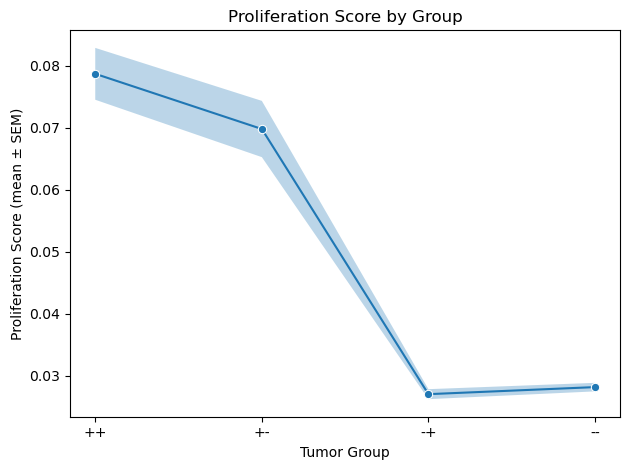

In [106]:

# Assume adata.obs contains 'GCLCVIM' and 'proliferation_score'
df = adata.obs.copy()

# Group by 'GCLCVIM' and calculate mean + standard error
summary = df.groupby('GCLCVIM')['proliferation_score'].agg(['mean', 'sem']).reset_index()

# Line plot with error bars
sns.lineplot(data=summary, x='GCLCVIM', y='mean', marker='o')
plt.fill_between(summary['GCLCVIM'], summary['mean'] - summary['sem'], summary['mean'] + summary['sem'], alpha=0.3)
plt.ylabel('Proliferation Score (mean ± SEM)')
plt.xlabel('Tumor Group')
plt.title('Proliferation Score by Group')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/scRNA/Signature_score/Proliferation_score_GCLCVIM_line_sc.pdf', dpi=500)
plt.show()


# Patient level

In [56]:
df_scores

,Patient,GCLCVIM,signature_anastasis,signature_proliferation,proliferation_score
CID4465_AATCCAGTCGGAATCT,CID4465,--,0.057139,0.028649,0.049997
CID4465_AGGCCACTCAATCACG,CID4465,--,-0.211850,0.185083,0.180271
CID4465_ATCACGACAATCGGTT,CID4465,--,0.003797,0.047876,0.076413
CID4465_CTACACCTCGAGCCCA,CID4465,--,-0.072127,0.115105,0.140380
CID4465_TGGTTAGGTATAAACG,CID4465,--,-0.180007,0.228370,0.254281
...,...,...,...,...,...
CID3963_GAACCTACACAGATTC,CID3963,--,-0.308466,-0.001009,-0.021985
CID3963_GCATGCGGTTCGAATC,CID3963,--,-0.302699,0.045975,0.055763
CID3963_GTACGTAGTGAGGGAG,CID3963,--,0.353898,-0.004652,0.024712
CID3963_TATTACCTCTTACCTA,CID3963,--,1.345855,0.006607,0.030812


In [78]:
balanced_df_scores

,Patient,GCLCVIM,signature_anastasis,signature_proliferation,proliferation_score
0,CID4515,++,-0.184580,0.182867,0.243887
1,CID4515,++,-0.042383,0.256477,0.311330
2,CID4513,++,-0.032831,-0.092503,-0.049175
3,CID4515,++,-0.322298,-0.029930,0.028973
4,CID4513,++,-0.256326,0.337011,0.397083
...,...,...,...,...,...
1995,CID44991,--,0.362023,-0.094650,-0.066194
1996,CID44991,--,0.334632,-0.015646,0.005194
1997,CID44991,--,0.439455,0.074691,0.114848
1998,CID4495,--,-0.207551,0.021660,0.010351


In [79]:
patient_df_scores = balanced_df_scores.groupby(['Patient', 'GCLCVIM'])[
    ['signature_anastasis', 'signature_proliferation', 'proliferation_score']
].median().reset_index()

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_61748/1091787956.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_df_scores = balanced_df_scores.groupby(['Patient', 'GCLCVIM'])[


In [80]:
patient_df_scores

,Patient,GCLCVIM,signature_anastasis,signature_proliferation,proliferation_score
0,CID3963,++,NaN,NaN,NaN
1,CID3963,+-,0.396288,-0.045666,-0.014230
2,CID3963,-+,-0.311615,-0.022548,-0.026406
3,CID3963,--,0.311194,-0.018873,0.009456
4,CID4465,++,NaN,NaN,NaN
5,CID4465,+-,-0.240195,0.231726,0.275755
6,CID4465,-+,NaN,NaN,NaN
7,CID4465,--,-0.087499,0.261785,0.295467
8,CID4495,++,-0.283976,0.001944,0.036541
9,CID4495,+-,-0.267044,0.004497,0.027339


In [81]:
from itertools import combinations, product
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

def cliffs_delta(x, y):
    """计算 Cliff's delta 非参数效应量"""
    n = sum([1 if a > b else -1 if a < b else 0 for a, b in product(x, y)])
    return n / (len(x) * len(y))

def group_compare_effects(df, group_col, signature_cols):
    results = []
    groups = df[group_col].unique()
    combs = list(combinations(groups, 2))
    
    for sig in signature_cols:
        for g1, g2 in combs:
            data1 = df[df[group_col] == g1][sig].dropna()
            data2 = df[df[group_col] == g2][sig].dropna()
            n1, n2 = len(data1), len(data2)
            if n1 < 2 or n2 < 2:
                p_val = np.nan
                delta = np.nan
            else:
                try:
                    stat, p_val = mannwhitneyu(data1, data2, alternative='two-sided')
                except Exception:
                    p_val = np.nan
                delta = cliffs_delta(data1, data2)
            median1 = np.median(data1) if n1>0 else np.nan
            median2 = np.median(data2) if n2>0 else np.nan
            results.append({
                'signature': sig,
                'Group1': g1,
                'Group2': g2,
                'p_value': p_val,
                'n1': n1,
                'n2': n2,
                'median1': median1,
                'median2': median2,
                'cliffs_delta': delta
            })
    
    res_df = pd.DataFrame(results)
    
    # 多重校正
    res_df['p_adj'] = np.nan
    for sig in signature_cols:
        mask = res_df['signature'] == sig
        pvals = res_df.loc[mask, 'p_value'].values
        valid = ~pd.isna(pvals)
        if valid.sum() > 0:
            _, p_adj, _, _ = multipletests(pvals[valid], method='fdr_bh')
            # 用 .loc 结合 index 赋值
            idx = res_df.loc[mask].index[valid]
            res_df.loc[idx, 'p_adj'] = p_adj
    
    return res_df


In [82]:
# patient_level_df 是你的数据
# 分组列名
group_col = 'GCLCVIM'
# signature列名列表
signature_cols = ['signature_anastasis', 'signature_proliferation', 'proliferation_score']

res = group_compare_effects(patient_df_scores, group_col, signature_cols)
print(res)


                  signature Group1 Group2   p_value  n1  n2   median1  \
0       signature_anastasis     ++     +-  0.648485   4   7 -0.152494   
1       signature_anastasis     ++     -+  1.000000   4   6 -0.152494   
2       signature_anastasis     ++     --  0.412121   4   7 -0.152494   
3       signature_anastasis     +-     -+  0.628205   7   6 -0.087691   
4       signature_anastasis     +-     --  0.804779   7   7 -0.087691   
5       signature_anastasis     -+     --  0.365967   6   7 -0.149597   
6   signature_proliferation     ++     +-  0.787879   4   7  0.028314   
7   signature_proliferation     ++     -+  0.609524   4   6  0.028314   
8   signature_proliferation     ++     --  0.527273   4   7  0.028314   
9   signature_proliferation     +-     -+  0.835664   7   6  0.004497   
10  signature_proliferation     +-     --  1.000000   7   7  0.004497   
11  signature_proliferation     -+     --  0.945221   6   7  0.004538   
12      proliferation_score     ++     +-  0.315152

In [ ]:
res

,signature,Group1,Group2,p_value,n1,n2,median1,median2,cliffs_delta,p_adj
0,signature_anastasis,++,+-,0.648485,4,7,-0.152494,-0.087691,-0.214286,0.965734
1,signature_anastasis,++,-+,1.000000,4,6,-0.152494,-0.149597,0.000000,1.000000
2,signature_anastasis,++,--,0.412121,4,7,-0.152494,-0.087499,-0.357143,0.965734
3,signature_anastasis,+-,-+,0.628205,7,6,-0.087691,-0.149597,0.190476,0.965734
4,signature_anastasis,+-,--,0.804779,7,7,-0.087691,-0.087499,-0.102041,0.965734
5,signature_anastasis,-+,--,0.365967,6,7,-0.149597,-0.087499,-0.333333,0.965734
6,signature_proliferation,++,+-,0.787879,4,7,0.028314,0.004497,0.142857,1.000000
7,signature_proliferation,++,-+,0.609524,4,6,0.028314,0.004538,0.250000,1.000000
8,signature_proliferation,++,--,0.527273,4,7,0.028314,-0.006516,0.285714,1.000000
9,signature_proliferation,+-,-+,0.835664,7,6,0.004497,0.004538,0.095238,1.000000
